# Tufa Labs ARC3 submission

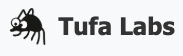

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")
print(
    "Q38-EVAL seed=1 mode=engine-swap-local25 "
    "engine=saltb0x/qwen3-8-27b-fp8 (Qwen3.8-27B-FP8, 25.3 GB, blockwise fp8) "
    "REPLACES driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot (Qwen3.6-27B-FP8, 35.9 GB) "
    "wheels=driessmit1/arc3-vllm-h100-wheelhouse-v3 (UNCHANGED, vLLM 0.19.0) "
    "reasoning_effort=PINNED-medium (renders byte-identically to the Qwen3.6 "
    "prompt; xhigh/low are a SEPARATE later arm) "
    "delta=THE WEIGHTS AND NOTHING ELSE; baseline family duck-harness-kaggle (m=3, lc 18/19/21)",
    flush=True,
)

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
# Q38-EVAL: the source bundle (index 0) and the wheelhouse are UNCHANGED; the engine
# entry is the ONE substitution. Order is preserved so index 0 stays the bundle.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "saltb0x/qwen3-8-27b-fp8"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
# --- Q38-EVAL BEGIN serve-config rewrite (FAIL-LOUD; no Qwen3.6 fallback) ---
# Anchored, counted, vetoed and invariant-checked. Any miss RAISES: a fallback here would
# silently serve the incumbent and produce a number we would read as an engine result.
# Failure policy is inverted vs the graft builds on purpose (same call the A17 canary made).
Q38_SETUP_REWRITES = [("MODEL_OWNER = 'driessmit1'", "MODEL_OWNER = 'saltb0x'"), ("MODEL_SLUG = 'vrfai-qwen3-6-27b-fp8-hf-snapshot'", "MODEL_SLUG = 'qwen3-8-27b-fp8'"), ("SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'", "SERVED_MODEL_NAME = 'Qwen/Qwen3.8-27B-FP8'"), ('\'{"preserve_thinking": true}\',', '\'{"preserve_thinking": true, "reasoning_effort": "medium"}\','), ('\n\ndef run_vllm_api_smoke_test() -> None:', '\n\nQ38_EXPECT_SERVED = \'Qwen/Qwen3.8-27B-FP8\'\nQ38_EFFORT = \'medium\'\nQ38_REQUIRED_FILES = (\n    \'config.json\', \'chat_template.jinja\', \'generation_config.json\', \'tokenizer.json\',\n    \'tokenizer_config.json\', \'preprocessor_config.json\', \'model.safetensors.index.json\',\n)\nQ38_PIN_CERTIFIED = []\n\n\ndef _q38_probe_messages():\n    # The shape the harness actually sends: a system message plus a tool list.\n    messages = [{\'role\': \'system\', \'content\': \'Q38_SYSTEM_SENTINEL\'},\n                {\'role\': \'user\', \'content\': \'hi\'}]\n    tools = [{\'type\': \'function\', \'function\': {\n        \'name\': \'submit_action\', \'description\': \'Submit the next ARC action.\',\n        \'parameters\': {\'type\': \'object\',\n                       \'properties\': {\'action\': {\'type\': \'string\'}, \'x\': {\'type\': \'integer\'},\n                                      \'y\': {\'type\': \'integer\'}},\n                       \'required\': [\'action\']}}}]\n    return messages, tools\n\n\ndef _q38_render_local(effort):\n    # Effort-pin instrument #1: render the ATTACHED template ourselves. No server, no\n    # transport, so this cannot fail for infrastructure reasons.\n    from jinja2.sandbox import ImmutableSandboxedEnvironment\n\n    def _raise(message):\n        raise ValueError(message)\n\n    env = ImmutableSandboxedEnvironment(trim_blocks=True, lstrip_blocks=True,\n                                        keep_trailing_newline=True)\n    env.globals[\'raise_exception\'] = _raise\n    env.filters[\'tojson\'] = lambda obj, **kw: json.dumps(obj, ensure_ascii=False)\n    template = env.from_string((MODEL_PATH / \'chat_template.jinja\').read_text(encoding=\'utf-8\'))\n    messages, tools = _q38_probe_messages()\n    kwargs = dict(messages=messages, tools=tools, add_generation_prompt=True,\n                  preserve_thinking=True, enable_thinking=True, add_vision_id=False)\n    if effort is not None:\n        kwargs[\'reasoning_effort\'] = effort\n    return template.render(**kwargs)\n\n\ndef _q38_png_b64(size: int = 64) -> str:\n    # Dependency-free solid-colour PNG for the boot MM probe.\n    import base64\n    import struct\n    import zlib\n\n    raw = (b\'\\x00\' + b\'\\xc8\\x32\\x32\' * size) * size\n\n    def _chunk(tag: bytes, data: bytes) -> bytes:\n        return (struct.pack(\'>I\', len(data)) + tag + data\n                + struct.pack(\'>I\', zlib.crc32(tag + data) & 0xFFFFFFFF))\n\n    ihdr = struct.pack(\'>IIBBBBB\', size, size, 8, 2, 0, 0, 0)\n    png = (b\'\\x89PNG\\r\\n\\x1a\\n\' + _chunk(b\'IHDR\', ihdr)\n           + _chunk(b\'IDAT\', zlib.compress(raw)) + _chunk(b\'IEND\', b\'\'))\n    return base64.b64encode(png).decode(\'ascii\')\n\n\ndef _q38_pre_serve_asserts() -> None:\n    # Runs BEFORE the 25 GB load. The 122B lane loaded 78 GB and only THEN found its\n    # snapshot was missing tokenizer_config/processor_config; every cheap check is here.\n    print(\'Q38-EVAL model_path=\' + str(MODEL_PATH), flush=True)\n    missing = [name for name in Q38_REQUIRED_FILES if not (MODEL_PATH / name).is_file()]\n    if missing:\n        raise RuntimeError(\'Q38-EVAL FATAL: engine snapshot is INCOMPLETE, missing \'\n                           + \', \'.join(missing) + \' under \' + str(MODEL_PATH)\n                           + \' - refusing to start a load that would die later\')\n    shards = sorted(MODEL_PATH.glob(\'layers-*.safetensors\'))\n    cfg = json.loads((MODEL_PATH / \'config.json\').read_text(encoding=\'utf-8\'))\n    quant = cfg.get(\'quantization_config\') or {}\n    text = cfg.get(\'text_config\') or {}\n    facts = {\n        \'architectures\': cfg.get(\'architectures\'),\n        \'model_type\': cfg.get(\'model_type\'),\n        \'transformers_version\': cfg.get(\'transformers_version\'),\n        \'image_token_id\': cfg.get(\'image_token_id\'),\n        \'quant_method\': quant.get(\'quant_method\'),\n        \'weight_block_size\': quant.get(\'weight_block_size\'),\n        \'activation_scheme\': quant.get(\'activation_scheme\'),\n        \'vocab_size\': text.get(\'vocab_size\'),\n        \'num_hidden_layers\': text.get(\'num_hidden_layers\'),\n        \'hidden_size\': text.get(\'hidden_size\'),\n        \'num_key_value_heads\': text.get(\'num_key_value_heads\'),\n        \'head_dim\': text.get(\'head_dim\'),\n        \'full_attention_interval\': text.get(\'full_attention_interval\'),\n        \'layer_shards\': len(shards),\n    }\n    print(\'Q38-EVAL engine-config \' + json.dumps(facts, sort_keys=True), flush=True)\n    # quant_method is the one field that CANNOT be true of Qwen3.6 (compressed-tensors W8A8\n    # per-tensor). If this passes, the attached weights are not the incumbent.\n    if quant.get(\'quant_method\') != \'fp8\' or quant.get(\'weight_block_size\') != [128, 128]:\n        raise RuntimeError(\'Q38-EVAL FATAL: quantization_config is not Qwen3.8 blockwise fp8: \'\n                           + json.dumps(quant, sort_keys=True)[:400]\n                           + \' - a silent Qwen3.6 run would poison the whole screen\')\n    if cfg.get(\'architectures\') != [\'Qwen3_5ForConditionalGeneration\']:\n        raise RuntimeError(\'Q38-EVAL FATAL: unexpected architectures \'\n                           + repr(cfg.get(\'architectures\')))\n    if not str(cfg.get(\'transformers_version\', \'\')).startswith(\'5.8\'):\n        raise RuntimeError(\'Q38-EVAL FATAL: transformers_version \'\n                           + repr(cfg.get(\'transformers_version\'))\n                           + \' is not the 5.8.x that wrote the Qwen3.8 release configs\')\n    for key, want in ((\'vocab_size\', 248320), (\'num_hidden_layers\', 64), (\'hidden_size\', 5120),\n                      (\'num_key_value_heads\', 4), (\'head_dim\', 256),\n                      (\'full_attention_interval\', 4)):\n        if text.get(key) != want:\n            raise RuntimeError(\'Q38-EVAL FATAL: text_config.\' + key + \' = \' + repr(text.get(key))\n                               + \' != \' + repr(want) + \' - NOT a drop-in for the incumbent\')\n    if cfg.get(\'image_token_id\') != 248056:\n        raise RuntimeError(\'Q38-EVAL FATAL: image_token_id drifted; the vision path would break\')\n    if len(shards) != 64:\n        raise RuntimeError(\'Q38-EVAL FATAL: expected 64 layer shards, found \' + str(len(shards)))\n\n    template_src = (MODEL_PATH / \'chat_template.jinja\').read_text(encoding=\'utf-8\')\n    if \'reasoning_effort\' not in template_src:\n        raise RuntimeError(\'Q38-EVAL FATAL: the attached chat template has no reasoning_effort \'\n                           \'knob - our pin would be a SILENT NO-OP and the arm would run at an \'\n                           \'unknown effort\')\n    try:\n        pinned = _q38_render_local(Q38_EFFORT)\n        control = _q38_render_local(None)      # positive control: the xhigh default\n    except Exception as exc:\n        print(\'Q38-EVAL WARN effort-pin local-render UNAVAILABLE (\' + repr(exc)[:200]\n              + \') - falling back to the server probe at boot\', flush=True)\n    else:\n        if \'easoning effort\' not in control:\n            print(\'Q38-EVAL WARN effort-pin local probe is BLIND (the xhigh default injected \'\n                  \'nothing), so its ABSENT proves nothing - auditing the instrument, not \'\n                  \'trusting it\', flush=True)\n        elif \'easoning effort\' in pinned:\n            raise RuntimeError(\'Q38-EVAL FATAL: reasoning_effort=\' + Q38_EFFORT + \' STILL \'\n                               \'injects an instruction - the prompt is not neutral and this arm \'\n                               \'would carry two variables, not one\')\n        elif \'Q38_SYSTEM_SENTINEL\' not in pinned:\n            raise RuntimeError(\'Q38-EVAL FATAL: the system message did not render\')\n        else:\n            Q38_PIN_CERTIFIED.append(\'local-render\')\n            print(\'Q38-EVAL effort-pin=\' + Q38_EFFORT + \' local-render reasoning_instruction=\'\n                  \'ABSENT control(default=xhigh)=PRESENT pinned_chars=\' + str(len(pinned))\n                  + \' control_chars=\' + str(len(control)), flush=True)\n\n    if shutil.which(\'nvidia-smi\'):\n        gpu = subprocess.run([\'nvidia-smi\', \'--query-gpu=name\', \'--format=csv,noheader\'],\n                             capture_output=True, text=True).stdout.strip()\n        print(\'Q38-EVAL gpu=\' + repr(gpu), flush=True)\n\n\ndef _q38_observe(tag, response, extra=\'\'):\n    # OBSERVATION BEFORE VERDICT. v1\'s MM assert printed the conclusion "the vision path is\n    # broken" and none of the evidence, so the question could not be closed from the log\n    # afterwards. Every probe now emits its raw observation first, pass or fail.\n    try:\n        message = response[\'choices\'][0][\'message\']\n        finish = response[\'choices\'][0].get(\'finish_reason\')\n    except Exception:\n        print(\'Q38-EVAL OBSERVE \' + tag + \' UNPARSEABLE body=\' + json.dumps(response)[:400],\n              flush=True)\n        return \'\', \'\'\n    content = (message.get(\'content\') or \'\')\n    reasoning = (message.get(\'reasoning_content\') or message.get(\'reasoning\') or \'\')\n    calls = message.get(\'tool_calls\') or []\n    usage = response.get(\'usage\') or {}\n    print(\'Q38-EVAL OBSERVE \' + tag\n          + \' finish_reason=\' + repr(finish)\n          + \' content_chars=\' + str(len(content))\n          + \' reasoning_chars=\' + str(len(reasoning))\n          + \' tool_calls=\' + str(len(calls))\n          + \' completion_tokens=\' + str(usage.get(\'completion_tokens\'))\n          + (\' \' + extra if extra else \'\')\n          + \' content_head=\' + repr(content[:120])\n          + \' reasoning_head=\' + repr(reasoning[:120]), flush=True)\n    return content.strip(), reasoning\n\n\ndef _q38_boot_asserts() -> None:\n    # Runs AFTER the server is up and the stock smoke test passed.\n    #\n    # CLASSIFICATION (prereg section 10, written before this code): a gate is FATAL only if its\n    # failure would make the number MEAN something other than what we would read it as. If the\n    # failure would simply BE the number, it is REPORT-ONLY. Two gates were reclassified after\n    # v1: the tool-call and MM probes. A broken tool-call path or a dead vision path produces a\n    # genuine low score for Qwen3.8-in-this-harness - that is a true measurement, not a\n    # poisoned one, and killing the kernel for it destroys the very number we came for.\n    models = request_json(VLLM_BASE_URL + \'/models\', timeout=60)\n    ids = sorted(entry.get(\'id\', \'\') for entry in models.get(\'data\', []))\n    if ids != [Q38_EXPECT_SERVED]:\n        raise RuntimeError(\'Q38-EVAL FATAL: served model ids \' + repr(ids) + \' != \'\n                           + repr([Q38_EXPECT_SERVED]) + \' - refusing to continue\')\n    print(\'Q38-EVAL served=\' + Q38_EXPECT_SERVED, flush=True)\n\n    # Effort-pin instrument #2: ask the SERVER what it renders. /tokenize is mounted at the\n    # ROOT, not under /v1 - v1 of this kernel appended it to VLLM_BASE_URL and got a 404. The\n    # endpoint existed; my URL was wrong. Same class as the payload bug: existence verified,\n    # call shape not. Transport failure stays non-fatal; a positive detection is fatal.\n    root_url = VLLM_BASE_URL[:-3] if VLLM_BASE_URL.endswith(\'/v1\') else VLLM_BASE_URL\n    root_url = root_url.rstrip(\'/\')\n    messages, tools = _q38_probe_messages()\n\n    def _rendered(extra):\n        kwargs = {\'enable_thinking\': True}\n        kwargs.update(extra)\n        payload = {\'model\': Q38_EXPECT_SERVED, \'messages\': messages, \'tools\': tools,\n                   \'add_generation_prompt\': True, \'return_token_strs\': True,\n                   \'chat_template_kwargs\': kwargs}\n        response = request_json(root_url + \'/tokenize\', payload=payload, timeout=120)\n        joined = \'\'.join(response.get(\'token_strs\') or [])\n        return joined.replace(\'\\u0120\', \' \').replace(\'\\u010a\', \'\\n\')\n\n    try:\n        served_prompt = _rendered({})\n        control_prompt = _rendered({\'reasoning_effort\': \'xhigh\'})\n    except Exception as exc:\n        served_prompt = \'\'\n        print(\'Q38-EVAL WARN effort-pin server-probe UNAVAILABLE at \' + root_url\n              + \'/tokenize (\' + repr(exc)[:200] + \')\', flush=True)\n    else:\n        print(\'Q38-EVAL OBSERVE tokenize served_chars=\' + str(len(served_prompt))\n              + \' control_chars=\' + str(len(control_prompt))\n              + \' served_head=\' + repr(served_prompt[:100]), flush=True)\n        if \'easoning effort\' not in control_prompt:\n            print(\'Q38-EVAL WARN effort-pin server-probe is BLIND (xhigh control produced no \'\n                  \'instruction) - not treating its ABSENT as evidence\', flush=True)\n        elif \'easoning effort\' in served_prompt:\n            raise RuntimeError(\'Q38-EVAL FATAL: the SERVED prompt contains a reasoning-effort \'\n                               \'instruction - --default-chat-template-kwargs did not bind and \'\n                               \'the arm carries two variables\')\n        else:\n            Q38_PIN_CERTIFIED.append(\'server-tokenize\')\n            print(\'Q38-EVAL effort-pin=\' + Q38_EFFORT + \' server-probe reasoning_instruction=\'\n                  \'ABSENT control_xhigh=PRESENT served_prompt_chars=\' + str(len(served_prompt)),\n                  flush=True)\n        if \'Q38_SYSTEM_SENTINEL\' in served_prompt and \'<think>\' in served_prompt:\n            print(\'Q38-EVAL preserve_thinking=BOUND (think block present in the served prompt)\',\n                  flush=True)\n\n    if not Q38_PIN_CERTIFIED:\n        raise RuntimeError(\'Q38-EVAL FATAL: the reasoning_effort pin is UNCERTIFIED by BOTH \'\n                           \'independent instruments. The arm would run at an unknown effort and \'\n                           \'the result would not isolate the weights. Dying at boot costs \'\n                           \'minutes; an uninterpretable 2h run costs the slot.\')\n    print(\'Q38-EVAL effort-pin-certified-by=\' + \',\'.join(Q38_PIN_CERTIFIED), flush=True)\n\n    # --- REPORT-ONLY from here down (prereg section 10, gates N/O/P) ---------------------\n    # Every payload below is HARNESS-SHAPED: chat_template_kwargs always present and\n    # max_tokens >= 256. v1 died because the MM probe omitted chat_template_kwargs and used\n    # max_tokens=32, so thinking stayed on, all 32 tokens went to reasoning_content, and\n    # `content` was empty - the MODAL behaviour of this stack, asserted on as if it were a\n    # fault. A static lint in q38_smoke.py now enforces both properties at build time.\n    forced = {\'model\': Q38_EXPECT_SERVED,\n              \'messages\': [{\'role\': \'user\',\n                            \'content\': \'Call the submit_action tool with action ACTION6, \'\n                                       \'x 3, y 7.\'}],\n              \'tools\': tools,\n              \'tool_choice\': {\'type\': \'function\', \'function\': {\'name\': \'submit_action\'}},\n              \'temperature\': 0.0, \'max_tokens\': 512,\n              \'chat_template_kwargs\': {\'enable_thinking\': False}}\n    try:\n        response = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=forced, timeout=300)\n        _q38_observe(\'tool-call-forced\', response)\n        calls = response[\'choices\'][0][\'message\'].get(\'tool_calls\') or []\n    except Exception as exc:\n        calls = []\n        print(\'Q38-EVAL WARN forced tool-call probe errored: \' + repr(exc)[:300], flush=True)\n    if calls and calls[0].get(\'function\', {}).get(\'name\') == \'submit_action\':\n        args = json.loads(calls[0][\'function\'].get(\'arguments\') or \'{}\')\n        print(\'Q38-EVAL tool-call-roundtrip=OK mode=forced args=\'\n              + json.dumps(args, sort_keys=True), flush=True)\n    else:\n        print(\'Q38-EVAL WARN tool-call-roundtrip=FAILED mode=forced - REPORT-ONLY: a broken \'\n              \'tool-call path yields a genuine low score, which IS the measurement. Watch the \'\n              \'bench for a zero-action signature.\', flush=True)\n\n    auto = dict(forced)\n    auto[\'tool_choice\'] = \'auto\'\n    auto[\'chat_template_kwargs\'] = {\'enable_thinking\': True}\n    auto[\'messages\'] = [{\'role\': \'user\', \'content\': \'Use the submit_action tool to submit \'\n                                                    \'ACTION6 at x 3, y 7. Reply with the tool \'\n                                                    \'call only.\'}]\n    try:\n        response = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=auto, timeout=300)\n        _q38_observe(\'tool-call-auto\', response)\n        calls = response[\'choices\'][0][\'message\'].get(\'tool_calls\') or []\n    except Exception as exc:\n        calls = []\n        print(\'Q38-EVAL WARN auto tool-call probe errored: \' + repr(exc)[:300], flush=True)\n    if calls:\n        print(\'Q38-EVAL tool-call-roundtrip=OK mode=auto parser=qwen3_coder name=\'\n              + str(calls[0].get(\'function\', {}).get(\'name\')), flush=True)\n    else:\n        print(\'Q38-EVAL WARN auto tool-call probe produced NO parsed call under qwen3_coder - \'\n              \'REPORT-ONLY\', flush=True)\n\n    # One real image through the vision tower. REPORT-ONLY (gate P): this is the assert that\n    # killed v1. Thinking is OFF and the budget is 512 so that an empty `content` means the\n    # vision path really is dead rather than that the model is still thinking.\n    payload = {\'model\': Q38_EXPECT_SERVED,\n               \'messages\': [{\'role\': \'user\', \'content\': [\n                   {\'type\': \'image_url\',\n                    \'image_url\': {\'url\': \'data:image/png;base64,\' + _q38_png_b64()}},\n                   {\'type\': \'text\', \'text\': \'Answer with one word: what colour is this image?\'}]}],\n               \'temperature\': 0.0, \'max_tokens\': 512,\n               \'chat_template_kwargs\': {\'enable_thinking\': False}}\n    try:\n        response = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=payload, timeout=300)\n        content, reasoning = _q38_observe(\'mm-image\', response)\n    except Exception as exc:\n        content, reasoning = \'\', \'\'\n        print(\'Q38-EVAL WARN MM probe errored (HTTP-level, i.e. the request was REJECTED rather \'\n              \'than answered - that is the signature of a genuinely broken vision path): \'\n              + repr(exc)[:300], flush=True)\n    if content:\n        print(\'Q38-EVAL mm-image-roundtrip=OK reply=\' + repr(content[:60]), flush=True)\n    else:\n        print(\'Q38-EVAL WARN mm-image-roundtrip=EMPTY-CONTENT reasoning_chars=\'\n              + str(len(reasoning)) + \' - REPORT-ONLY: a dead vision path would produce a low \'\n              \'score, which IS the number. Read this against the per-game traces, not as a \'\n              \'reason to kill the run.\', flush=True)\n\n    print(\'Q38-EVAL BOOT-ASSERTS PASSED - handing off to the 25-game offline bench\', flush=True)\n\n\ndef run_vllm_api_smoke_test() -> None:'), ('\nstart_vllm_server()\nrun_vllm_api_smoke_test()\n', '\n_q38_pre_serve_asserts()\nstart_vllm_server()\nrun_vllm_api_smoke_test()\n_q38_boot_asserts()\n')]
Q38_VETO = ('vrfai-qwen3-6-27b-fp8-hf-snapshot', 'vrfai/Qwen3.6-27B-FP8')
Q38_REQUIRE = ('saltb0x', 'qwen3-8-27b-fp8', 'Qwen/Qwen3.8-27B-FP8', '"reasoning_effort": "medium"', '_q38_pre_serve_asserts()', '_q38_boot_asserts()', 'Q38-EVAL')
Q38_INVARIANTS = ("WHEELHOUSE_OWNER = 'driessmit1'", "WHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3'", "'--tool-call-parser',\n        'qwen3_coder',", "'--reasoning-parser',\n        'qwen3',", "'--enable-prefix-caching',", "'--generation-config',\n        'vllm',", '"preserve_thinking": true', 'VLLM_MAX_MODEL_LEN = 65536', 'ANALYZER_CONTEXT_WINDOW = 32768', 'VLLM_TENSOR_PARALLEL_SIZE = 1', "'LOCAL_ANALYZER_TEMPERATURE': '0.6'", "'LOCAL_ANALYZER_TOP_P': '0.95'", "'LOCAL_ANALYZER_TOP_K': '20'", "'LOCAL_ANALYZER_ENABLE_THINKING': 'true'", "'MULTIMODAL_CONTEXT': 'current_grid'", "'MULTIMODAL_UPSCALE': '4'", "'LOCAL_ANALYZER_YIELD_SECONDS': '60'", "STAMP_TEXT = 'vllm==0.19.0 torch==2.10.0 flashinfer==0.6.6\\n'")


def _q38_patch_setup_commands(commands):
    if not isinstance(commands, list) or len(commands) != 1:
        raise RuntimeError('Q38-EVAL FATAL: expected exactly 1 setup command, got '
                           + repr(commands)[:200])
    command = commands[0]
    for invariant in Q38_INVARIANTS:
        if command.count(invariant) < 1:
            raise RuntimeError('Q38-EVAL FATAL: pristine setup command is missing the '
                               'invariant %r - the bundle drifted and this arm is no longer '
                               'a one-variable change' % (invariant[:80],))
    for old, new in Q38_SETUP_REWRITES:
        found = command.count(old)
        if found != 1:
            raise RuntimeError('Q38-EVAL FATAL: serve-config anchor matched %d times '
                               '(want 1): %r' % (found, old[:100]))
        command = command.replace(old, new)
    for veto in Q38_VETO:
        if veto in command:
            raise RuntimeError('Q38-EVAL FATAL: incumbent serve artifact %r survived the '
                               'rewrite' % (veto,))
    for need in Q38_REQUIRE:
        if need not in command:
            raise RuntimeError('Q38-EVAL FATAL: required Qwen3.8 serve token %r missing '
                               'after rewrite' % (need,))
    for invariant in Q38_INVARIANTS:
        if invariant not in command:
            raise RuntimeError('Q38-EVAL FATAL: the rewrite destroyed the invariant %r - '
                               'more than one variable changed' % (invariant[:80],))
    print('Q38-EVAL setup-commands rewrite OK (%d anchors replaced, %d invariants held; '
          'loud-fail mode, no incumbent fallback)'
          % (len(Q38_SETUP_REWRITES), len(Q38_INVARIANTS)), flush=True)
    return [command]


# --- Q38-EVAL END serve-config rewrite ---
for command in _q38_patch_setup_commands(
        json.loads((BUNDLE_DIR / "setup_commands.json").read_text())):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")